# EDS 232 — Task 1: Potential Problems in Linear Regression

**One-sentence overview:** This notebook explores three common violations of linear regression assumptions using synthetic data, diagnostic plots, and (where relevant) remedial comparisons.

---

## How to read this notebook (what is yours vs. what is AI-assisted)

| Label | Meaning |
|-------|--------|
| **✏️ STUDENT** | **You must write this in your own words** for the assignment. Leaving these sections blank will lose points on explanations and open questions. |
| **🤖 AI-assisted code** | Python was drafted to match the assignment brief (synthetic data + plots). **You are still responsible** for running all cells, checking outputs, and explaining what the code does in your **✏️ STUDENT** sections. |

**Before submitting:** Kernel → Restart & Run All; confirm every cell ran and every figure appears.

## Imports and settings

**🤖 AI-assisted code** — standard libraries for simulation, OLS, and diagnostics.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

rng = np.random.default_rng(232)

plt.rcParams.update({
    "figure.figsize": (7, 4),
    "axes.grid": True,
    "grid.alpha": 0.25,
})

---

# Issue 1 — Non-linearity of the response–predictor relationship

### ✏️ STUDENT — Short paragraph (required)

Write **your own** short paragraph (roughly 4–8 sentences) that covers:

1. **What** the problem is (in plain language).
2. **Why** it matters for inference and/or prediction under a linear model.
3. **How to detect** it (name at least one diagnostic you can actually point to on a plot below).
4. **How to address** it, if applicable (e.g., transformations, polynomials/splines, different model class).

*Replace this bullet list with your paragraph:*

- …

### ✏️ STUDENT — Question from the reading + your investigated answer (required)

**Question you could not fully answer from ISLR alone:**

- …

**Answer you found (cite source: textbook section / lecture / documentation / etc.):**

- …

### 🧾 Plot caption (integrate into your paragraph or write 2–3 sentences here)

**✏️ STUDENT:** Describe what each figure shows and how it supports your claims.

- …

### 🤖 AI-assisted code — synthetic data, wrong (linear) fit, and a better (quadratic) comparison

True relationship is quadratic; we deliberately fit **ordinary least squares (OLS) linear** regression to illustrate structured residuals.

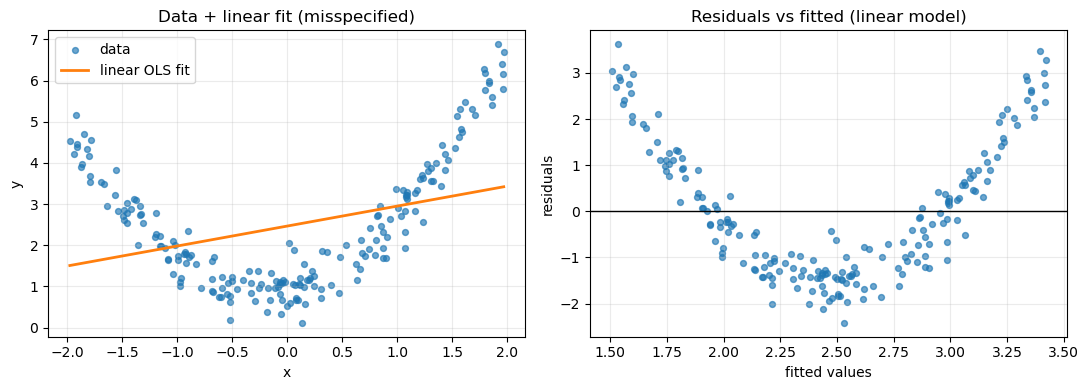

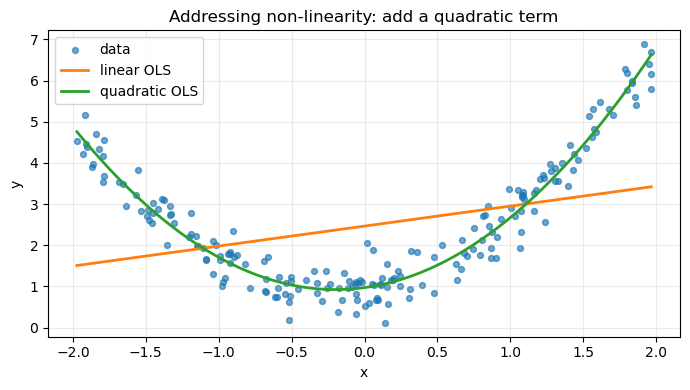

Linear model R^2: 0.1199
Quadratic model R^2: 0.9425


In [2]:
n = 200
x = rng.uniform(-2, 2, size=n)
y_true = 1.0 + 0.5 * x + 1.2 * (x ** 2)  # quadratic signal
y = y_true + rng.normal(0, 0.35, size=n)

X_lin = sm.add_constant(x)
ols_lin = sm.OLS(y, X_lin).fit()

X_quad = sm.add_constant(np.column_stack([x, x ** 2]))
ols_quad = sm.OLS(y, X_quad).fit()

xgrid = np.linspace(x.min(), x.max(), 200)
Xg_lin = sm.add_constant(xgrid)
Xg_quad = sm.add_constant(np.column_stack([xgrid, xgrid ** 2]))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(x, y, s=18, alpha=0.65, label="data")
axes[0].plot(xgrid, ols_lin.predict(Xg_lin), color="C1", lw=2, label="linear OLS fit")
axes[0].set_title("Data + linear fit (misspecified)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend()

r_lin = ols_lin.resid
axes[1].scatter(ols_lin.fittedvalues, r_lin, s=18, alpha=0.65)
axes[1].axhline(0, color="black", lw=1)
axes[1].set_title("Residuals vs fitted (linear model)")
axes[1].set_xlabel("fitted values")
axes[1].set_ylabel("residuals")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(x, y, s=18, alpha=0.65, label="data")
ax.plot(xgrid, ols_lin.predict(Xg_lin), color="C1", lw=2, label="linear OLS")
ax.plot(xgrid, ols_quad.predict(Xg_quad), color="C2", lw=2, label="quadratic OLS")
ax.set_title("Addressing non-linearity: add a quadratic term")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
plt.tight_layout()
plt.show()

print("Linear model R^2:", round(ols_lin.rsquared, 4))
print("Quadratic model R^2:", round(ols_quad.rsquared, 4))

---

# Issue 2 — Non-constant variance of error terms (heteroscedasticity)

### ✏️ STUDENT — Short paragraph (required)

Same structure as Issue 1: what / why / detection / remedies (e.g., weighted least squares, robust SEs, variance-stabilizing transforms).

*Replace with your paragraph:*

- …

### ✏️ STUDENT — Question from the reading + your investigated answer (required)

**Question:**

- …

**Investigated answer:**

- …

### ✏️ STUDENT — Plot caption (2–3 sentences)

- …

### 🤖 AI-assisted code — fan-shaped noise + residual vs fitted + WLS comparison

Noise standard deviation increases with `x`, so OLS yields a **funnel** in residuals vs fitted values. The follow-up uses **weighted least squares** with weights proportional to **1 / true error variance** at each `x` from the data-generating process (an “oracle” choice for teaching; in practice you estimate weights, transform the response, or use heteroskedasticity-robust standard errors).

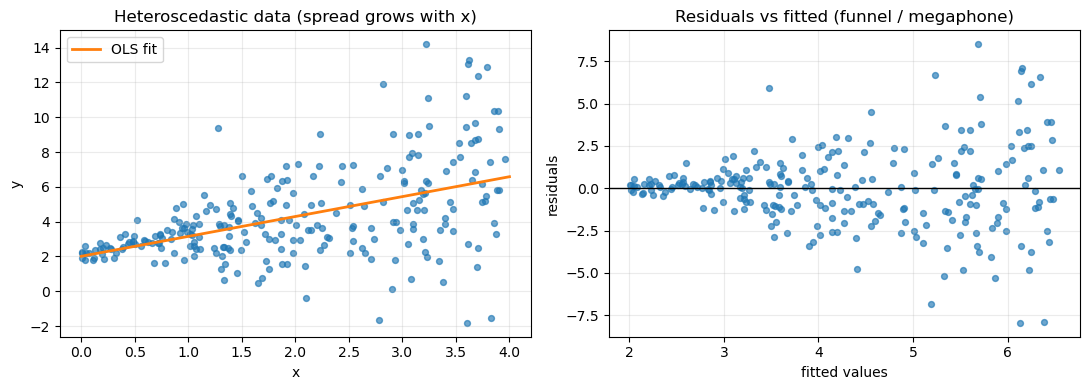

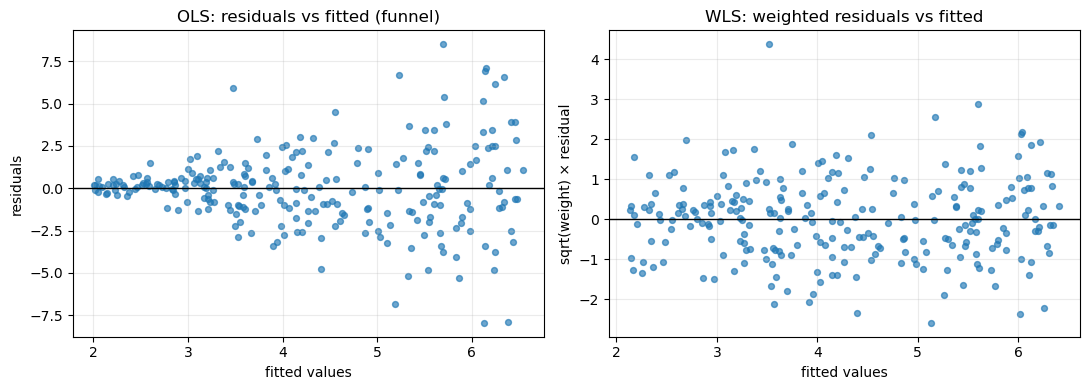

In [3]:
n = 250
x = rng.uniform(0, 4, size=n)
sigma = 0.25 + 0.85 * x  # variance grows with x
eps = rng.normal(0, sigma)
y = 2.0 + 1.1 * x + eps

X = sm.add_constant(x)
ols_het = sm.OLS(y, X).fit()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(x, y, s=18, alpha=0.65)
xx = np.linspace(0, 4, 200)
axes[0].plot(xx, ols_het.predict(sm.add_constant(xx)), color="C1", lw=2, label="OLS fit")
axes[0].set_title("Heteroscedastic data (spread grows with x)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend()

r = ols_het.resid
fv = ols_het.fittedvalues
axes[1].scatter(fv, r, s=18, alpha=0.65)
axes[1].axhline(0, color="black", lw=1)
axes[1].set_title("Residuals vs fitted (funnel / megaphone)")
axes[1].set_xlabel("fitted values")
axes[1].set_ylabel("residuals")

plt.tight_layout()
plt.show()

# Addressing illustration: WLS with weights inversely proportional to true Var(eps_i)
var_eps = sigma ** 2
wls = sm.WLS(y, X, weights=1.0 / var_eps).fit()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(fv, r, s=18, alpha=0.65)
axes[0].axhline(0, color="black", lw=1)
axes[0].set_title("OLS: residuals vs fitted (funnel)")
axes[0].set_xlabel("fitted values")
axes[0].set_ylabel("residuals")

axes[1].scatter(wls.fittedvalues, wls.wresid, s=18, alpha=0.65)
axes[1].axhline(0, color="black", lw=1)
axes[1].set_title("WLS: weighted residuals vs fitted")
axes[1].set_xlabel("fitted values")
axes[1].set_ylabel("sqrt(weight) × residual")

plt.tight_layout()
plt.show()

---

# Issue 3 — Collinearity

### ✏️ STUDENT — Short paragraph (required)

Cover: what / why (unstable coefficients, inflated SEs, interpretability) / detection (correlation matrix, VIF) / remedies (drop/merge predictors, regularization, collect more data).

*Replace with your paragraph:*

- …

### ✏️ STUDENT — Question from the reading + your investigated answer (required)

**Question:**

- …

**Investigated answer:**

- …

### ✏️ STUDENT — Plot caption (2–3 sentences)

- …

### 🤖 AI-assisted code — nearly redundant predictors + VIF + coefficient instability illustration

We construct `x2 ≈ x1` with a tiny independent perturbation, then compare OLS when both are included vs. when one is dropped.

VIFs (predictors only; intercept excluded from VIF table):
x1    461.68
x2    461.68


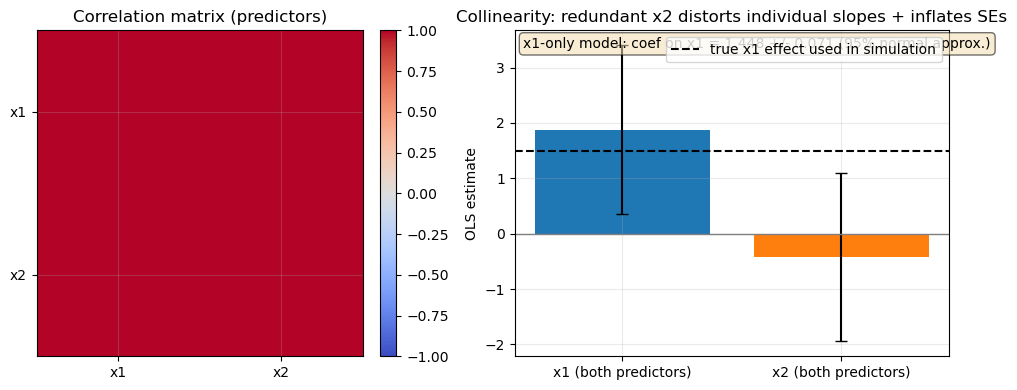


Model with x1 + x2:
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0113      0.038     26.655      0.000       0.936       1.086
x1             1.8781      0.779      2.410      0.017       0.341       3.415
x2            -0.4281      0.774     -0.553      0.581      -1.955       1.099

Model with x1 only:
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0118      0.038     26.721      0.000       0.937       1.086
x1             1.4479      0.036     39.994      0.000       1.376       1.519


In [4]:
n = 200
x1 = rng.normal(0, 1, size=n)
x2 = x1 + rng.normal(0, 0.05, size=n)  # very high correlation
eps = rng.normal(0, 0.5, size=n)
y = 1.0 + 1.5 * x1 + 0.0 * x2 + eps  # true effect only through x1 (x2 is redundant)

df = pd.DataFrame({"const": 1.0, "x1": x1, "x2": x2})
ols_both = sm.OLS(y, df[["const", "x1", "x2"]]).fit()
ols_x1 = sm.OLS(y, df[["const", "x1"]]).fit()

X_pred = df[["x1", "x2"]].to_numpy(dtype=float)
vif_tbl = pd.Series(
    [variance_inflation_factor(X_pred, j) for j in range(X_pred.shape[1])],
    index=["x1", "x2"],
    name="VIF",
)
print("VIFs (predictors only; intercept excluded from VIF table):")
print(vif_tbl.round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

im = axes[0].imshow(df[["x1", "x2"]].corr(), vmin=-1, vmax=1, cmap="coolwarm")
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(["x1", "x2"])
axes[0].set_yticklabels(["x1", "x2"])
axes[0].set_title("Correlation matrix (predictors)")
plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

coef_both = ols_both.params[["x1", "x2"]]
se_both = ols_both.bse[["x1", "x2"]]
xlab = ["x1 (both predictors)", "x2 (both predictors)"]
axes[1].bar(xlab, coef_both, yerr=1.96 * se_both, capsize=4, color=["C0", "C1"])
axes[1].axhline(1.5, color="black", ls="--", lw=1.5, label="true x1 effect used in simulation")
axes[1].axhline(0, color="gray", lw=1)
axes[1].set_ylabel("OLS estimate")
axes[1].set_title("Collinearity: redundant x2 distorts individual slopes + inflates SEs")
axes[1].legend(loc="best")
note = (
    f"x1-only model: coef on x1 = {ols_x1.params['x1']:.3f} "
    f"+/- {1.96 * ols_x1.bse['x1']:.3f} (95% normal approx.)"
)
axes[1].text(0.02, 0.98, note, transform=axes[1].transAxes, va="top", fontsize=10, bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.55))

plt.tight_layout()
plt.show()

print("\nModel with x1 + x2:")
print(ols_both.summary().tables[1])
print("\nModel with x1 only:")
print(ols_x1.summary().tables[1])

---

# Generative AI reflection (assignment step 4)

### ✏️ STUDENT — Write 4–6 sentences (required)

Address all of the following **in your own words**:

1. **Which tool** you used (e.g., ChatGPT, Claude, Copilot, etc.).
2. **What prompts** you gave (paraphrase is fine; paste if allowed).
3. **How many iterations** it took to get working code.
4. **Mistakes the AI made** (if any) and **how you noticed and fixed** them.

*Your reflection:*

- I gave Cursor (auto) the task 1 instructions in Agent mode and gave it the prompt "Give me .ipynb make clear whats AI and what I need to answer. No mistakes." Took only one iteration because cursor is way too powerful and detrimental to my learning, I stopped using it when I realized how much it effected my cognition, retention and education in general (which didnt take long) so it was fun to open it up again and release the reigns letting it do whatever it wanted with the assignment. I'm pretty sure it even did the class readings LOL. Some things to note are that Cursor on auto doesnt tell me what model it used. Could have been Chat, Claudia or copilot, I'll never really know, and I sincerely apologize as now one of them has the task 1 description, but it didnt seem sensitive and kind of the point of this assignment to use it so